Comparing Model XGB, Logistic Regression, Random Forrest

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))


In [2]:
def preprocess_features(x):

    high_cardinality_cols = [
        "transaction_id",
        "sender_account",
        "receiver_account",
        "ip_address",
        "device_hash"
    ]

    x = x.drop(columns=high_cardinality_cols, errors="ignore")

    x["timestamp"] = pd.to_datetime(
        x["timestamp"],
        format="ISO8601"
    )

    x["hour"] = x["timestamp"].dt.hour
    x["day_of_week"] = x["timestamp"].dt.dayofweek
    x["is_weekend"] = (x["day_of_week"] >= 5).astype(int)

    x = x.drop(
        columns=["timestamp", "fraud_type"],
        errors="ignore"
    )

    categorical_cols = [
        "transaction_type",
        "merchant_category",
        "location",
        "device_used",
        "payment_channel"
    ]

    x = pd.get_dummies(
        x,
        columns=categorical_cols,
        drop_first=True
    )

    return x

In [3]:
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False

from src.preprocessing import AmountTimeScaler, split_x_y
from src.utils import metrics_at_threshold, threshold_for_target_recall, summarize

DATA_PROCESSED = Path("../data/processed")
train = pd.read_csv(DATA_PROCESSED / "batch1_train.csv")
test  = pd.read_csv(DATA_PROCESSED / "batch2_test.csv")
stream1 = pd.read_csv(DATA_PROCESSED / "batch3_stream.csv")
stream2 = pd.read_csv(DATA_PROCESSED / "batch4_stream.csv")


In [4]:
x_train_full, y_train_full = split_x_y(train)
x_tr, x_val, y_tr, y_val = train_test_split(
    x_train_full, y_train_full, test_size=0.2, stratify=y_train_full, random_state=42
)


In [5]:
x_tr = preprocess_features(x_tr)
x_val = preprocess_features(x_val)

x_tr, x_val = x_tr.align(
    x_val,
    join="left",
    axis=1,
    fill_value=0
)

train_medians = x_tr.median(numeric_only=True)

x_tr = x_tr.fillna(train_medians)
x_val = x_val.fillna(train_medians)

In [6]:
print(x_tr.shape)
print(x_tr.select_dtypes(include=["object","string"]).columns.tolist())

(100000, 31)
[]


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False

models = {
    "LogReg": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "RF": RandomForestClassifier(
        n_estimators=400,
        n_jobs=-1,
        random_state=42,
        class_weight="balanced_subsample",
    ),
}

if HAS_XGB:
    models["XGB"] = XGBClassifier(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        n_jobs=-1,
        random_state=42,
        # you can also try: scale_pos_weight = (num_neg / num_pos)
    )
else:
    # fallback so we still have 3 models
    models["GB"] = GradientBoostingClassifier(random_state=42)


In [8]:
TARGET_RECALL = 0.80
results = {}

def fit_and_threshold(name, clf):
    pipe = Pipeline([
        ("clf", clf),
    ])
    pipe.fit(x_tr, y_tr)
    val_scores = pipe.predict_proba(x_val)[:,1]
    thr = threshold_for_target_recall(y_val, val_scores, TARGET_RECALL)
    results[name] = {"pipe": pipe, "thr": thr}

for name, clf in models.items():
    fit_and_threshold(name, clf)

{k: v["thr"] for k, v in results.items()}


C:\Users\HP\.conda\envs\fraud-detection-drift-aware\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'LogReg': 0.5, 'RF': 0.5, 'GB': 0.5}

In [9]:
import inspect
print(inspect.getsource(threshold_for_target_recall))

def threshold_for_target_recall(y_true, y_score, target_recall=0.8, min_thr=1e-3, max_flagged=0.2):
    from sklearn.metrics import precision_recall_curve
    prec, rec, thr = precision_recall_curve(y_true, y_score)
    # Compute fraction flagged for each candidate threshold
    flagged_frac = [(y_score >= t).mean() for t in thr]
    best_thr = 0.5
    for r, f, t in zip(rec[1:], flagged_frac, thr):
        if r >= target_recall and f <= max_flagged and t >= min_thr:
            best_thr = float(t)
            break
    return best_thr



In [10]:
for name, obj in results.items():

    pipe = obj["pipe"]

    scores = pipe.predict_proba(x_val)[:,1]

    print(name)
    print("min score:", scores.min())
    print("max score:", scores.max())
    print("mean score:", scores.mean())
    print()

LogReg
min score: 0.39971760643775794
max score: 0.5851096041406116
mean score: 0.4985531985994344

RF
min score: 0.0
max score: 0.2425
mean score: 0.0349771

GB
min score: 0.0018459693382573373
max score: 0.6232210476823101
mean score: 0.035152409907543446



In [11]:
from sklearn.metrics import precision_recall_curve

scores = results["LogReg"]["pipe"].predict_proba(x_val)[:,1]

prec, rec, thr = precision_recall_curve(y_val, scores)

print("Max recall:", rec.max())

Max recall: 1.0


In [12]:
for name, obj in results.items():
    scores = obj["pipe"].predict_proba(x_val)[:,1]

    print(name)

    for t in [0.01,0.05,0.1,0.2,0.3,0.4,0.5]:
        print(
            t,
            "flagged=",
            round((scores >= t).mean(),3)
        )

    print()

LogReg
0.01 flagged= 1.0
0.05 flagged= 1.0
0.1 flagged= 1.0
0.2 flagged= 1.0
0.3 flagged= 1.0
0.4 flagged= 1.0
0.5 flagged= 0.49

RF
0.01 flagged= 0.893
0.05 flagged= 0.226
0.1 flagged= 0.011
0.2 flagged= 0.0
0.3 flagged= 0.0
0.4 flagged= 0.0
0.5 flagged= 0.0

GB
0.01 flagged= 0.822
0.05 flagged= 0.038
0.1 flagged= 0.002
0.2 flagged= 0.001
0.3 flagged= 0.001
0.4 flagged= 0.0
0.5 flagged= 0.0



In [13]:
for name, obj in results.items():

    scores = obj["pipe"].predict_proba(x_val)[:,1]

    print("\n", name)

    for t in [0.01,0.03,0.05,0.1]:
        m = metrics_at_threshold(y_val, scores, t)

        flagged = (scores >= t).mean()

        print(
            f"thr={t:.2f}",
            f"recall={m['recall']:.3f}",
            f"precision={m['precision']:.3f}",
            f"flagged={flagged:.3f}"
        )


 LogReg
thr=0.01 recall=1.000 precision=0.035 flagged=1.000
thr=0.03 recall=1.000 precision=0.035 flagged=1.000
thr=0.05 recall=1.000 precision=0.035 flagged=1.000
thr=0.10 recall=1.000 precision=0.035 flagged=1.000

 RF
thr=0.01 recall=0.992 precision=0.039 flagged=0.893
thr=0.03 recall=0.725 precision=0.043 flagged=0.586
thr=0.05 recall=0.289 precision=0.045 flagged=0.226
thr=0.10 recall=0.013 precision=0.041 flagged=0.011

 GB
thr=0.01 recall=0.998 precision=0.043 flagged=0.822
thr=0.03 recall=0.976 precision=0.043 flagged=0.802
thr=0.05 recall=0.048 precision=0.044 flagged=0.038
thr=0.10 recall=0.003 precision=0.073 flagged=0.002


In [14]:
print(x_tr.columns.tolist())

['amount', 'time_since_last_transaction', 'spending_deviation_score', 'velocity_score', 'geo_anomaly_score', 'hour', 'day_of_week', 'is_weekend', 'transaction_type_payment', 'transaction_type_transfer', 'transaction_type_withdrawal', 'merchant_category_grocery', 'merchant_category_online', 'merchant_category_other', 'merchant_category_restaurant', 'merchant_category_retail', 'merchant_category_travel', 'merchant_category_utilities', 'location_Dubai', 'location_London', 'location_New York', 'location_Singapore', 'location_Sydney', 'location_Tokyo', 'location_Toronto', 'device_used_mobile', 'device_used_pos', 'device_used_web', 'payment_channel_UPI', 'payment_channel_card', 'payment_channel_wire_transfer']


In [15]:
print(x_tr.shape)
print(x_tr.select_dtypes(include=["object","string"]).columns.tolist())

(100000, 31)
[]


In [16]:
def evaluate_on_batches(pipe, thr):

    table = []

    for label, df in [
        ("TEST", test),
        ("STREAM1", stream1),
        ("STREAM2", stream2)
    ]:

        x, y = split_x_y(df)

        x = preprocess_features(x)

        x = x.reindex(
            columns=x_tr.columns,
            fill_value=0
        )

        x = x.fillna(train_medians)

        scores = pipe.predict_proba(x)[:,1]

        table.append(
            summarize(y, scores, thr).assign(batch=label)
        )

    out = pd.concat(table, ignore_index=True)

    return out[
        [
            "batch",
            "threshold",
            "precision",
            "recall",
            "f1",
            "pr_auc",
            "TP",
            "FP",
            "TN",
            "FN",
            "flagged",
            "flagged_pct"
        ]
    ]


In [17]:
all_model_tables = {
    name: evaluate_on_batches(v["pipe"], v["thr"])
    for name, v in results.items()
}

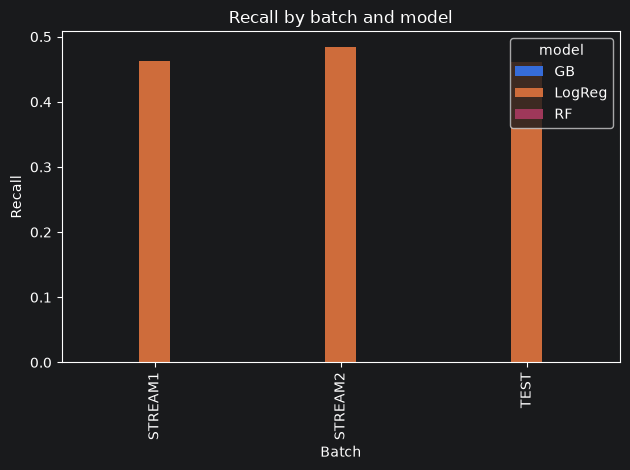

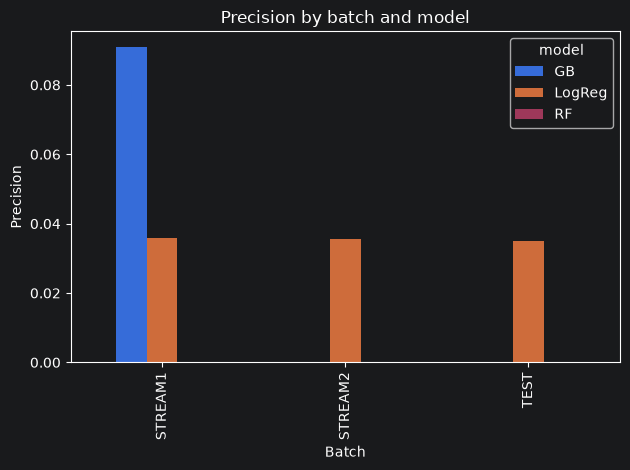

In [18]:
import matplotlib.pyplot as plt

# combine all into one df
df_all = []
for name, df in all_model_tables.items():
    df_all.append(df.assign(model=name))
df_all = pd.concat(df_all, ignore_index=True)

# plot recall per batch per model
for metric in ["recall", "precision"]:
    pivoted = df_all.pivot(index="batch", columns="model", values=metric)
    ax = pivoted.plot(kind="bar")
    ax.set_title(f"{metric.capitalize()} by batch and model")
    ax.set_ylabel(metric.capitalize())
    ax.set_xlabel("Batch")
    plt.tight_layout()
    plt.show()


In [19]:
from inspect import getsource
from src import utils
print(getsource(utils.threshold_for_target_recall))


def threshold_for_target_recall(y_true, y_score, target_recall=0.8, min_thr=1e-3, max_flagged=0.2):
    from sklearn.metrics import precision_recall_curve
    prec, rec, thr = precision_recall_curve(y_true, y_score)
    # Compute fraction flagged for each candidate threshold
    flagged_frac = [(y_score >= t).mean() for t in thr]
    best_thr = 0.5
    for r, f, t in zip(rec[1:], flagged_frac, thr):
        if r >= target_recall and f <= max_flagged and t >= min_thr:
            best_thr = float(t)
            break
    return best_thr

